(-0.5, 4079.5, 3059.5, -0.5)

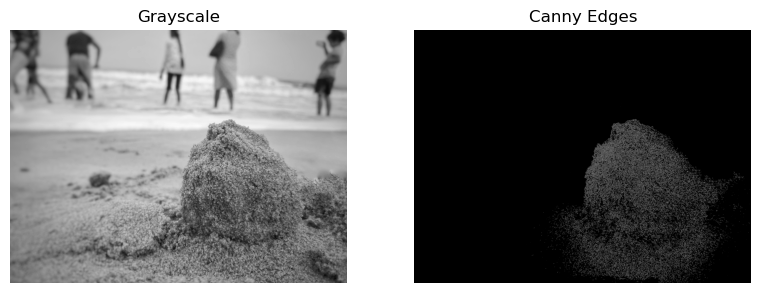

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("1.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ------------------------------
# 1. Edge Detection (Canny)
# ------------------------------
edges = cv2.Canny(gray, 100, 100)

plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis("off")

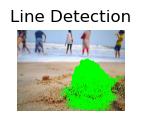

In [53]:
# 2. Line Detection (HoughLinesP)

lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50)

line_img = img.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1,y1), (x2,y2), (0,255,0), 10) #GREEN COLOR WITH RADIUS 10

plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.title("Line Detection")
plt.axis("off")

plt.show()

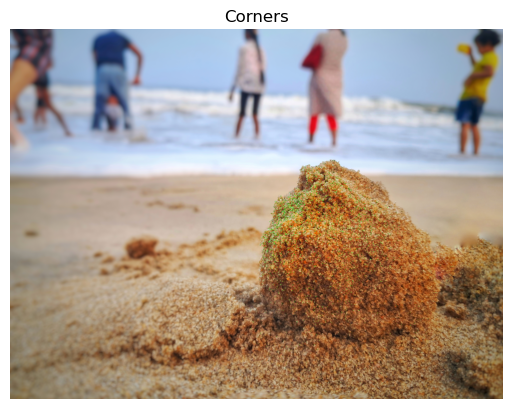

In [55]:
# 2. Corner Detection (cornerHarris)

corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)

# Mark corners
img[corners > 0.01 * corners.max()] = [0, 255, 0]

# Show
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Corners")
plt.axis("off")
plt.show()